# Итоговый проект: «От дерева решений к ансамблю и кластеризации»

## Задание

**Проект** поможет увидеть, как на практике решаются задачи анализа данных — от простых правил до более сложных алгоритмов.

Вы научитесь строить алгоритмы, которые сами находят закономерности в данных, и поймёте, как такие методы применяются, например, при разделении клиентов на группы, прогнозе событий или оценке качества решений.

Проект даст вам опыт «взрослой» аналитической работы, когда нужно не просто обработать таблицу, а объяснить, почему модель принимает именно такие решения.

**Цель проекта**

Цель проекта — закрепить понимание принципов работы алгоритмов деревьев решений, ансамблей и кластеризации через собственную реализацию и анализ их поведения на данных.

В ходе проекта вы:

* реализуете базовые версии алгоритмов с нуля, используя numpy и pandas;
* проведёте эксперименты с параметрами и сравните результаты с реализациями из sklearn;
* научитесь интерпретировать результаты и визуализировать их.

**Формат выполнения**
1. Проект выполняется индивидуально.
2. Результат — Jupyter Notebook (.ipynb):
    * с описанием цели и задач проекта;
    * кодом с комментариями;
    * визуализациями и таблицами;
    * краткими выводами по каждому этапу.
3. В конце ноутбука добавьте общий вывод: чему вы научились и какие особенности алгоритмов заметили.

## Этапы проекта

### Этап 1. Реализация дерева решений (15 баллов)
На этом этапе вы создаёте простую реализацию дерева решений для задачи классификации.

#### Что нужно сделать

1. Сгенерируйте небольшой набор данных (100–300 наблюдений) с помощью функции:

```from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=200,
    n_features=2,  # два признака для наглядной визуализации границ решений
    n_informative=2,
    n_redundant=0,
    random_state=42
)
```
2. Преобразуйте данные в pandas.DataFrame.

3. Реализуйте функции:

* расчёта критерия Джини или энтропии;
* поиска наилучшего разбиения по признаку;
* рекурсивного построения дерева с ограничением по глубине (max_depth) или по числу объектов в узле (min_samples_split);
* предсказания для новых наблюдений.

#### Тестирование модели
1. Разделите данные на обучающую и тестовую выборки (например, с помощью train_test_split, зафиксировав random_state=42 для воспроизводимости).
2. Сравните результаты своей реализации с DecisionTreeClassifier из sklearn. Разрешается использовать этот класс только для сверки корректности.
3. Постройте график границ решений (если данных 2D) с помощью matplotlib.

#### Результат
* Таблица с точностью (accuracy) на обучении и тесте.
* Визуализация дерева или границ решений.
* Краткий комментарий о различиях вашей реализации и sklearn.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


# from sklearn import tree
# from sklearn import datasets
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


,feature_1,feature_2,target
0,1.689767,-1.408241,1
1,1.530287,-1.459848,1
2,-1.175042,-1.447633,0
3,-2.585395,0.963532,0
4,1.372246,0.440695,1


target
1    100
0    100
Name: count, dtype: int64

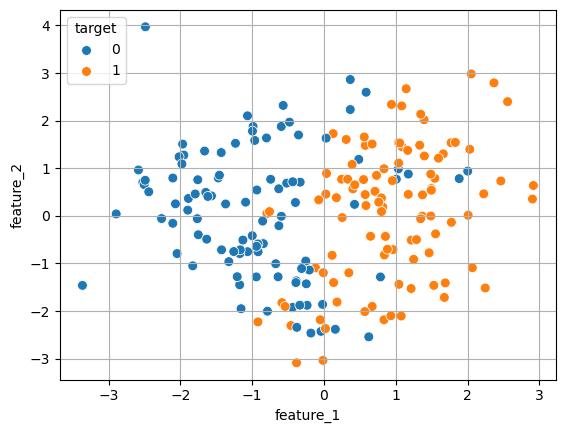

In [20]:
# Генерация данных
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42,
)

# Преобразование в pandas.DataFrame
# Объединяем признаки X и целевую переменную y в один DataFrame
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
# преобразуем "X" в DataFrame
X = df.copy()
df['target'] = y
# преобразуем "y" в DataFrame
y = df['target']
display(df.head())

display(df.target.value_counts())

sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='target', s=50) # s - размер точек, hue - категория цвета
plt.legend(title='target') # Добавляем легенду
plt.grid(True) # Необязательно: добавляем сетку
plt.show()

In [23]:
def find_candidates_for_thresholds(x, y):
    x = x.sort_values().drop_duplicates()
    x_roll_mean = x.rolling(2).mean().dropna()
    y = y[x_roll_mean.index]
    y_roll_mean = y.diff()
    candidates = x_roll_mean[y_roll_mean != 0]
    return candidates.values

print("Количество кандидатов для разбиения у feature_1:", 
      find_candidates_for_thresholds(df['feature_1'], df['target']).shape[0])
print("Количество кандидатов для разбиения у feature_2:", 
      find_candidates_for_thresholds(df['feature_2'], df['target']).shape[0])

def squared_error(y):
    y_pred = y.mean()
    return ((y - y_pred) ** 2).mean()

def gini(y):
    p = y.value_counts(normalize=True)
    gini_impurity = 1 - np.sum(p**2)
    return gini_impurity

def entropy(y):
    p = y.value_counts(normalize=True)
    entropy = -np.sum(p * np.log2(p))
    return entropy

def split(X, y, split_params):
    j, t = split_params
    predicat = X.iloc[:, j] <= t
    X_left, y_left = X[predicat], y[predicat]
    # В pandas для булевой индексации необходимо использовать побитовые операторы ~ (NOT), & (AND), | (OR).
    X_right, y_right = X[~predicat], y[~predicat]
    return X_left, y_left, X_right, y_right

def calculate_weighted_impurity(X, y, split_params, criterion):
    X_left, y_left, X_right, y_right = split(X, y, split_params)
    N, N_left, N_right  = y.size, y_left.size, y_right.size
    score = N_left / N * criterion(y_left) + N_right / N * criterion(y_right)
    return score

def best_split(X, y, criterion):
    M = X.shape[1]
    min_weighted_impurity = np.inf
    optimal_split_params = None
    for j in range(M):
        thresholds = find_candidates_for_thresholds(X.iloc[:, j], y)
        for t in thresholds:
            split_params = (j, t)
            weighted_impurity = calculate_weighted_impurity(X, y, split_params, criterion)
            if weighted_impurity < min_weighted_impurity:
                min_weighted_impurity = weighted_impurity
                optimal_split_params = split_params
    return optimal_split_params

# Находим оптимальные параметры разбиения
criterion_list = [gini, entropy, squared_error]
for elem in criterion_list:
    optimal_split_params = best_split(X, y, criterion=elem)
    print(str(elem).split()[1], '-'*5, 'Optimal j: {}'.format(optimal_split_params[0]), 'Optimal t: {}'.format(optimal_split_params[1]))

class Node:
    def __init__(self, left=None, 
                 right=None, value=None, 
                 split_params=None, impurity=None,
                 samples=None, is_leaf=False):
        self.left = left
        self.right = right
        self.split_params = split_params
        self.value = value
        self.impurity = impurity
        self.samples = samples
        self.is_leaf = is_leaf

def create_leaf_prediction(y):
    value = y.mode()[0]
    return value

def stopping_criterion(X, y, criterion, max_depth=None, depth=0):
    if max_depth is None:
        return (criterion(y) == 0) 
    else:
        return (criterion(y) == 0) or (depth > max_depth)
    
def build_decision_tree(X, y, criterion, max_depth=None, depth=0):
    depth += 1
    if stopping_criterion(X, y, criterion, max_depth, depth):
        value = create_leaf_prediction(y)
        node = Node(
            value=value, 
            impurity=criterion(y), 
            samples=y.size,
            is_leaf=True
        )
    else:
        split_params = best_split(X, y, criterion)
        X_left, y_left, X_rigth, y_right = split(X, y, split_params)
        left = build_decision_tree(X_left, y_left, criterion, max_depth, depth)
        right = build_decision_tree(X_rigth, y_right, criterion, max_depth, depth)       
        node = Node(
            left=left, right=right, 
            split_params=split_params, 
            impurity=criterion(y), 
            samples=y.size
        )
    return node

def print_decision_tree(node, depth=0):
    depth += 1
    if node.is_leaf:
        print('   ' * depth, 'class: {}'.format(node.value))
    else:
        print('   ' * depth, 'feature_{} <= {:.3f}:'.format(*node.split_params))
        print_decision_tree(node.left, depth=depth)
        print('   ' * depth, 'feature_{} > {:.3f}:'.format(*node.split_params))
        print_decision_tree(node.right, depth=depth)

def predict_sample(node, x):
    if node.is_leaf:
        return node.value
    j, t = node.split_params
    if x[j] <= t:
        return predict_sample(node.left, x)
    else:
        return predict_sample(node.right, x)  

def predict(decision_tree, X):
    predictions = [predict_sample(decision_tree, x) for x in X.values]
    return np.array(predictions)

Количество кандидатов для разбиения у feature_1: 38
Количество кандидатов для разбиения у feature_2: 110
gini ----- Optimal j: 0 Optimal t: -0.1502000994422335
entropy ----- Optimal j: 0 Optimal t: -0.1502000994422335
squared_error ----- Optimal j: 0 Optimal t: -0.1502000994422335


РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ
              Модель  Accuracy на обучении  Accuracy на тесте
    Кастомное дерево              0.885714           0.833333
Sklearn DecisionTree              0.885714           0.833333



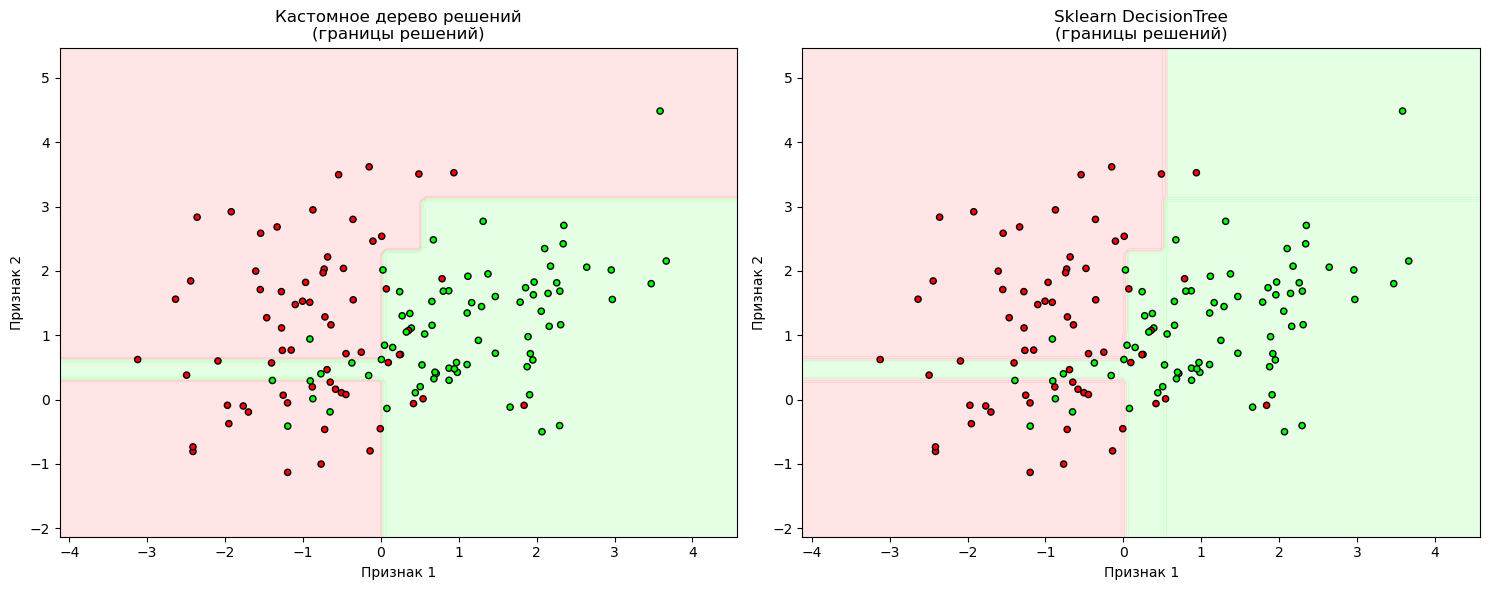


СТРУКТУРА КАСТОМНОГО ДЕРЕВА РЕШЕНИЙ
[feature1 <= -0.000]
  [feature2 <= 0.569]
    [feature2 <= 0.280]
      Лист: класс = 0
    [feature2 > 0.280]
      Лист: класс = 1
  [feature2 > 0.569]
    [feature2 <= 1.027]
      Лист: класс = 0
    [feature2 > 1.027]
      Лист: класс = 0
[feature1 > -0.000]
  [feature1 <= 0.552]
    [feature2 <= 2.276]
      Лист: класс = 1
    [feature2 > 2.276]
      Лист: класс = 0
  [feature1 > 0.552]
    [feature2 <= 3.148]
      Лист: класс = 1
    [feature2 > 3.148]
      Лист: класс = 0

ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ


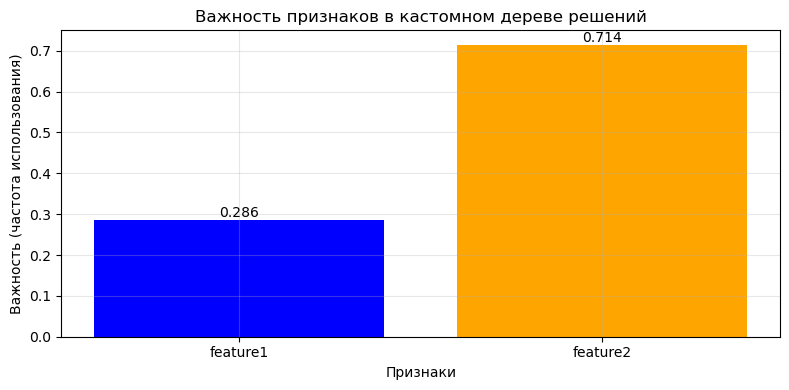

In [46]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Параметры
max_depth=10
min_samples_split=5
criterion=gini

# Обучение кастомной модели
custom_tree = CustomDecisionTree(max_depth=10, min_samples_split=5, criterion='gini')
custom_tree.fit(X_train, y_train)

# Предсказания
y_train_pred_custom = custom_tree.predict(X_train)
y_test_pred_custom = custom_tree.predict(X_test)

# 6. Обучение sklearn модели для сравнения
sklearn_tree = DecisionTreeClassifier(
    max_depth=3, 
    min_samples_split=10,
    random_state=42
)
sklearn_tree.fit(X_train, y_train)

y_train_pred_sklearn = sklearn_tree.predict(X_train)
y_test_pred_sklearn = sklearn_tree.predict(X_test)

# 7. Вычисление accuracy
train_acc_custom = accuracy_score(y_train, y_train_pred_custom)
test_acc_custom = accuracy_score(y_test, y_test_pred_custom)
train_acc_sklearn = accuracy_score(y_train, y_train_pred_sklearn)
test_acc_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

# Создание таблицы с результатами
results_df = pd.DataFrame({
    'Модель': ['Кастомное дерево', 'Sklearn DecisionTree'],
    'Accuracy на обучении': [train_acc_custom, train_acc_sklearn],
    'Accuracy на тесте': [test_acc_custom, test_acc_sklearn]
})

print("=" * 60)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ")
print("=" * 60)
print(results_df.to_string(index=False))
print("\n" + "=" * 60)

# 8. Визуализация границ решений
def plot_decision_boundaries(model, X, y, title, ax):
    """Функция для визуализации границ решений"""
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])
    
    # Сетка для построения границ
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Предсказания для точек сетки
    if hasattr(model, 'predict_proba'):
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    Z = Z.reshape(xx.shape)
    
    # Построение границ
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='black', s=20)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

# Создание графиков
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Визуализация для кастомного дерева
plot_decision_boundaries(custom_tree, X_train, y_train, 
                        'Кастомное дерево решений\n(границы решений)', axes[0])

# Визуализация для sklearn дерева
plot_decision_boundaries(sklearn_tree, X_train, y_train, 
                        'Sklearn DecisionTree\n(границы решений)', axes[1])

plt.tight_layout()
plt.show()

# 9. Визуализация структуры дерева (упрощенная)
def print_tree_structure(node, depth=0, feature_names=None):
    """Рекурсивная печать структуры дерева"""
    indent = "  " * depth
    
    if node.value is not None:
        print(f"{indent}Лист: класс = {node.value}")
        return
    
    if feature_names is None:
        feature_name = f"Признак {node.feature_idx}"
    else:
        feature_name = feature_names[node.feature_idx]
    
    print(f"{indent}[{feature_name} <= {node.threshold:.3f}]")
    print_tree_structure(node.left, depth + 1, feature_names)
    print(f"{indent}[{feature_name} > {node.threshold:.3f}]")
    print_tree_structure(node.right, depth + 1, feature_names)

print("\n" + "=" * 60)
print("СТРУКТУРА КАСТОМНОГО ДЕРЕВА РЕШЕНИЙ")
print("=" * 60)
print_tree_structure(custom_tree.root, feature_names=['feature1', 'feature2'])

# 10. Дополнительная визуализация: график важности признаков
def plot_feature_importance(tree_model, feature_names):
    """Визуализация важности признаков (упрощенная)"""
    # Оцениваем важность признаков по частоте использования в дереве
    feature_counts = {name: 0 for name in feature_names}
    
    def count_features(node):
        if node.value is not None:  # Лист
            return
        
        feature_counts[feature_names[node.feature_idx]] += 1
        count_features(node.left)
        count_features(node.right)
    
    count_features(tree_model.root)
    
    # Нормализуем значения
    total = sum(feature_counts.values())
    if total > 0:
        feature_importance = {k: v/total for k, v in feature_counts.items()}
    else:
        feature_importance = feature_counts
    
    # Создаем график
    fig, ax = plt.subplots(figsize=(8, 4))
    features = list(feature_importance.keys())
    importance = list(feature_importance.values())
    
    bars = ax.bar(features, importance, color=['blue', 'orange'])
    ax.set_xlabel('Признаки')
    ax.set_ylabel('Важность (частота использования)')
    ax.set_title('Важность признаков в кастомном дереве решений')
    ax.grid(True, alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar, imp in zip(bars, importance):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{imp:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ")
print("=" * 60)
plot_feature_importance(custom_tree, ['feature1', 'feature2'])

In [ ]:
# Строим дерево решений и печатаем его на экран
decision_tree = build_decision_tree(X, y, criterion=entropy)
# print_decision_tree(decision_tree)

Количество кандидатов для разбиения у feature_1: 38
Количество кандидатов для разбиения у feature_2: 110
Optimal j: 0
Optimal t: -0.1502000994422335


In [21]:
# Создаем модель дерева решений
dt = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    random_state=1000 #генератор случайных чисел
)
dt.fit(X, y)
# Печатаем дерево решений в виде списка условий
# print(tree.export_text(decision_tree=dt))

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1000
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:


# Предсказываем целевую переменную
y_pred = predict(decision_tree, X)
print('Predictions:\n {}'.format(y_pred))

Predictions:
 [1 1 0 0 1 1 0 0 0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 0
 1 0 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0
 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 1 1 0 1 1 0 1 0 1 0 1 1 1 0 0 0 0 1 0 0
 0 1 0 0 1 0 1 1 0 0 1 0 0 1 0 0 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1 1 0 1 0 0 0
 0 0 1 0 1 1 1 1 0 1 1 0 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 1 1 0 1 0 0 0 1
 0 1 0 1 0 1 1 0 1 1 0 1 0 1 0]


In [23]:
len(y_pred)

200

In [24]:

# Строим дерево решений с ограничением глубины и печатаем его на экран
decision_tree = build_decision_tree(X, y, criterion=entropy, max_depth=2)
print_decision_tree(decision_tree)

    feature_0 <= -0.150:
       feature_1 <= -1.641:
          class: 0
       feature_1 > -1.641:
          class: 0
    feature_0 > -0.150:
       feature_1 <= -2.375:
          class: 0
       feature_1 > -2.375:
          class: 1


In [25]:
def calculate_feature_importances(node, feature_importance=None):
    if feature_importance is None:
        feature_importance = np.zeros(X.shape[1])
    if node.value is None:
        j = node.split_params[0]
        feature_importance[j] += node.impurity * node.samples - \
                                 node.left.impurity * node.left.samples - \
                                 node.right.impurity * node.right.samples
        calculate_feature_importances(node.left, feature_importance)
        calculate_feature_importances(node.right, feature_importance)
    feature_importance /= node.samples
    feature_importance /= feature_importance.sum()
    return feature_importance

In [26]:
# Строим дерево решений и печатаем его на экран
decision_tree = build_decision_tree(X, y, entropy)
# Считаем информативности признаков
print(calculate_feature_importances(decision_tree))

[0.0643045 0.9356955]


##### practice 7 OOP

In [33]:
class SimpleDecisionTreeClassifier:
    """
    Реализация решающего дерева.
    Кодирует метки в 0..n_classes_-1 и гарантирует, что в node['value']
    всегда векторы длины self.n_classes_.
    Поддерживает 'gini' и 'entropy', max_depth, min_samples_leaf.
    """
    def __init__(self, criterion='gini', max_depth=None, min_samples_leaf=1):
        assert criterion in ('gini', 'entropy')
        self.criterion = criterion
        self.max_depth = max_depth if max_depth is None else int(max_depth)
        self.min_samples_leaf = int(min_samples_leaf)

        # будут заполнены в fit()
        self.tree_ = None
        self.n_classes_ = None
        self.classes_ = None
        self.class_to_index_ = None

    def _gini(self, y):
        probs = np.bincount(y, minlength=self.n_classes_) / len(y)
        return 1.0 - np.sum(probs**2)

    def _entropy(self, y):
        probs = np.bincount(y, minlength=self.n_classes_) / len(y)
        probs = probs[probs > 0]
        return -np.sum(probs * np.log2(probs))

    def _impurity(self, y):
        # вычисляет "неопределённость" (impurity) узла, чтобы понимать,
        # насколько неоднородны метки в данной подвыборке
        if len(y) == 0:
            return 0.0
        return self._gini(y) if self.criterion == 'gini' else self._entropy(y)

    def _best_split(self, X, y):
        # Размер выборки и число признаков
        n_samples, n_features = X.shape
        if n_samples <= 1:
            # Невозможно разделить менее одного объекта
            return None, None, None, None

        # Импульс (неопределённость) родительского узла
        parent_impurity = self._impurity(y)

        # Инициализация переменных для лучшего разбиения
        best_gain = 0.0
        best_feat = None
        best_thresh = None
        best_left_idx = None

        # Перебор всех признаков
        for feature in range(n_features):
            values = X[:, feature]
            # Сортировка значений признака для упрощения поиска порогов
            sorted_idx = np.argsort(values)
            values_sorted = values[sorted_idx]
            y_sorted = y[sorted_idx]

            # Рассмотрение всех возможных порогов между соседними значениями
            for i in range(1, n_samples):
                # Пропускаем одинаковые значения
                if values_sorted[i] == values_sorted[i-1]:
                    continue
                # Среднее между соседними значениями как кандидат порога
                thresh = (values_sorted[i] + values_sorted[i-1]) / 2.0

                # Создаем маску для левой и правой подвыборки
                left_mask = values <= thresh
                left_count = np.sum(left_mask)
                right_count = n_samples - left_count

                # Проверяем ограничение на минимальное количество объектов в листе
                if left_count < self.min_samples_leaf or right_count < self.min_samples_leaf:
                    continue

                # Вычисляем impurity (Gini/Entropy) для левой и правой подвыборок
                left_imp = self._impurity(y[left_mask])
                right_imp = self._impurity(y[~left_mask])

                # Взвешенное среднее по числу объектов
                weighted_imp = (left_count * left_imp + right_count * right_imp) / n_samples

                # Прирост информации (или уменьшение impurity)
                gain = parent_impurity - weighted_imp

                # Сохраняем лучшее разбиение
                if gain > best_gain:
                    best_gain = gain
                    best_feat = feature
                    best_thresh = thresh
                    best_left_idx = left_mask

        # Возвращаем лучший признак, порог, маску для левой подвыборки и прирост
        return best_feat, best_thresh, best_left_idx, best_gain


    def _build_tree(self, X, y, depth=0):
        num_samples = X.shape[0]
        num_classes_in_node = len(np.unique(y))
        node = {}
        node['n_samples'] = num_samples
        # гарантируем одинаковую длину value: minlength=self.n_classes_
        node['value'] = np.bincount(y, minlength=self.n_classes_).astype(int).tolist()
        node['predicted_class'] = int(np.argmax(node['value']))

        # условия останова
        if self.max_depth is not None and depth >= self.max_depth:
            node['is_leaf'] = True
            return node

        if num_samples <= 2 * self.min_samples_leaf or num_classes_in_node == 1:
            node['is_leaf'] = True
            return node

        feat, thresh, left_mask, gain = self._best_split(X, y)
        if feat is None or gain <= 0:
            node['is_leaf'] = True
            return node

        node['is_leaf'] = False
        node['feature'] = int(feat)
        node['threshold'] = float(thresh)
        node['left'] = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        node['right'] = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        return node

    def fit(self, X, y):
        # Поддержка pandas
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, (pd.Series, pd.DataFrame)):
            y_arr = np.asarray(y).ravel()
        else:
            y_arr = np.asarray(y)

        # Кодируем метки в 0..n_classes_-1
        self.classes_, y_encoded = np.unique(y_arr, return_inverse=True)
        self.n_classes_ = len(self.classes_)
        # map original -> encoded index (необязательно, но удобно)
        self.class_to_index_ = {c: i for i, c in enumerate(self.classes_)}

        self.n_features_ = X.shape[1]
        # строим дерево на закодированных метках
        self.tree_ = self._build_tree(X, y_encoded, depth=0)
        return self

    def _predict_one(self, x, node):
        if node.get('is_leaf', True):
            return node['predicted_class']
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        else:
            return self._predict_one(x, node['right'])

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        preds_idx = [self._predict_one(x, self.tree_) for x in X]
        # преобразуем индексы обратно в оригинальные метки
        return np.array([self.classes_[i] for i in preds_idx])

    def _predict_proba_one(self, x, node):
        if node.get('is_leaf', True):
            counts = np.array(node['value'], dtype=float)
            probs = counts / counts.sum() if counts.sum() > 0 else np.zeros(self.n_classes_, dtype=float)
            return probs
        if x[node['feature']] <= node['threshold']:
            return self._predict_proba_one(x, node['left'])
        else:
            return self._predict_proba_one(x, node['right'])

    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        probs = np.vstack([self._predict_proba_one(x, self.tree_) for x in X])
        return probs

Сравнение: наша реализация vs sklearn

In [34]:
def print_metrics(name, y_true, y_pred, y_prob=None):
    print(f'-- {name} --')
    print('Accuracy:', accuracy_score(y_true, y_pred))
    print('Precision:', precision_score(y_true, y_pred))
    print('Recall:', recall_score(y_true, y_pred))
    print('F1:', f1_score(y_true, y_pred))
    if y_prob is not None:
        try:
            print('ROC AUC:', roc_auc_score(y_true, y_prob))
        except Exception as e:
            print('ROC AUC: error', e)
    print('Confusion matrix:\n', confusion_matrix(y_true, y_pred))
    print()

In [35]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train our simple tree (gini) and sklearn tree with similar parameters
simple_tree = SimpleDecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=5)
simple_tree.fit(X_train, y_train)

sk_tree = DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=5, random_state=42)
sk_tree.fit(X_train, y_train)

# Predictions & probabilities
y_pred_simple = simple_tree.predict(X_test)
y_pred_sk = sk_tree.predict(X_test)
y_prob_simple = simple_tree.predict_proba(X_test)[:, 1]  # probability for class 1
y_prob_sk = sk_tree.predict_proba(X_test)[:, 1]

# Metrics function
print_metrics('Simple tree (gini)', y_test, y_pred_simple, y_prob_simple)
print_metrics('sklearn tree (gini)', y_test, y_pred_sk, y_prob_sk)

-- Simple tree (gini) --
Accuracy: 0.85
Precision: 0.8181818181818182
Recall: 0.9
F1: 0.8571428571428571
ROC AUC: 0.8844444444444445
Confusion matrix:
 [[24  6]
 [ 3 27]]

-- sklearn tree (gini) --
Accuracy: 0.85
Precision: 0.8181818181818182
Recall: 0.9
F1: 0.8571428571428571
ROC AUC: 0.8844444444444445
Confusion matrix:
 [[24  6]
 [ 3 27]]



Демонстрация переобучения (Synthetic dataset)

Натренируем дерево с большой максимальной глубиной и покажем, что оно переобучается.
Затем применим регулизацию (ограничение глубины и min_samples_leaf) и сравним метрики.

In [37]:
# Helper to evaluate different depths
def evaluate_depths(depths, min_samples_leaf=1):
    train_scores = []
    test_scores = []
    for d in depths:
        clf = DecisionTreeClassifier(max_depth=d, min_samples_leaf=min_samples_leaf, random_state=42)
        clf.fit(X_train_s, y_train_s)
        train_scores.append(clf.score(X_train_s, y_train_s))
        test_scores.append(clf.score(X_test_s, y_test_s))
    return train_scores, test_scores


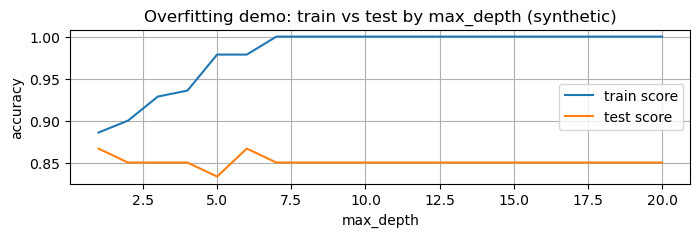

In [41]:
# Train/test split for synthetic
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

depths = list(range(1, 21))
train_scores, test_scores = evaluate_depths(depths, min_samples_leaf=1)

plt.figure(figsize=(8,2))
plt.plot(depths, train_scores, label='train score')
plt.plot(depths, test_scores, label='test score')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.title('Overfitting demo: train vs test by max_depth (synthetic)')
plt.legend()
plt.grid(True)
plt.show()

Регуляризация

Покажем влияние `min_samples_leaf` и `ccp_alpha` (скользящая регуляризация стоимости сложности) на качество.

   min_samples_leaf  train_acc  test_acc
0                 1   1.000000  0.850000
1                 5   0.907143  0.850000
2                10   0.885714  0.866667
3                20   0.885714  0.866667
4                50   0.885714  0.866667

Number of candidate alphas: 12


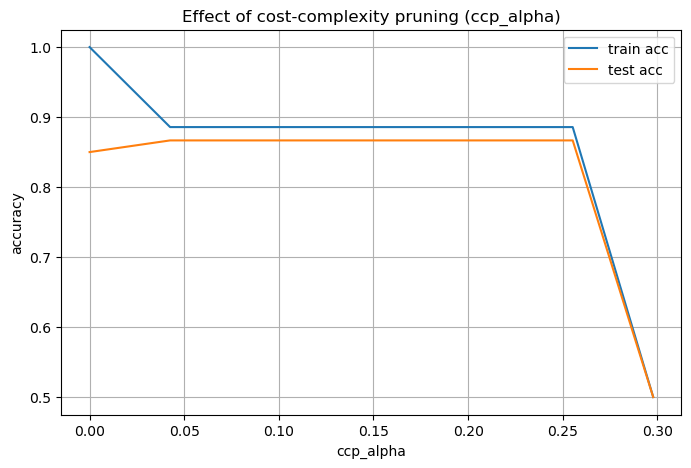

In [42]:
# Vary min_samples_leaf
leaf_vals = [1, 5, 10, 20, 50]
results = []
for leaf in leaf_vals:
    clf = DecisionTreeClassifier(max_depth=None, min_samples_leaf=leaf, random_state=42)
    clf.fit(X_train_s, y_train_s)
    results.append((leaf, clf.score(X_train_s, y_train_s), clf.score(X_test_s, y_test_s)))

df_res = pd.DataFrame(results, columns=['min_samples_leaf', 'train_acc', 'test_acc'])
print(df_res)

# Cost complexity pruning path (sklearn) - compute effective alphas
clf_full = DecisionTreeClassifier(random_state=42)
path = clf_full.cost_complexity_pruning_path(X_train_s, y_train_s)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
print('\nNumber of candidate alphas:', len(ccp_alphas))

# Train trees for some alphas and plot test accuracy
train_scores = []
test_scores = []
alphas_to_test = np.linspace(ccp_alphas.min(), ccp_alphas.max(), num=8)
for a in alphas_to_test:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=float(a))
    clf.fit(X_train_s, y_train_s)
    train_scores.append(clf.score(X_train_s, y_train_s))
    test_scores.append(clf.score(X_test_s, y_test_s))

plt.figure(figsize=(8,5))
plt.plot(alphas_to_test, train_scores, label='train acc')
plt.plot(alphas_to_test, test_scores, label='test acc')
plt.xlabel('ccp_alpha')
plt.ylabel('accuracy')
plt.title('Effect of cost-complexity pruning (ccp_alpha)')
plt.legend()
plt.grid(True)
plt.show()

Извлечение правил из собственной реализации

Функция ниже рекурсивно обходит дерево и выводит правила в виде текста — удобно для бизнес-правил и экспертных систем.


In [43]:
def tree_to_rules(node, feature_names, prefix='IF '):
    # returns list of strings, each is a rule leading to a leaf with prediction and samples
    if node.get('is_leaf', True):
        prob = np.array(node['value'], dtype=float)
        prob = prob / prob.sum()
        return [f"{prefix} THEN predict={node['predicted_class']} (samples={node['n_samples']}, prob={prob.tolist()})"]
    # left rule
    f = feature_names[node['feature']]
    thresh = node['threshold']
    left_prefix = prefix + f"{f} <= {thresh:.4f} AND "
    right_prefix = prefix + f"{f} > {thresh:.4f} AND "
    left_rules = tree_to_rules(node['left'], feature_names, left_prefix)
    right_rules = tree_to_rules(node['right'], feature_names, right_prefix)
    return left_rules + right_rules

print('Rules from simple_tree:')
rules = tree_to_rules(simple_tree.tree_, list(X.columns))
for r in rules[:10]:
    print(r)

Rules from simple_tree:
IF feature_1 <= -0.0185 AND feature_2 <= -1.6351 AND feature_1 <= -0.3808 AND  THEN predict=1 (samples=7, prob=[0.2857142857142857, 0.7142857142857143])
IF feature_1 <= -0.0185 AND feature_2 <= -1.6351 AND feature_1 > -0.3808 AND  THEN predict=0 (samples=6, prob=[1.0, 0.0])
IF feature_1 <= -0.0185 AND feature_2 > -1.6351 AND feature_1 <= -0.7807 AND  THEN predict=0 (samples=40, prob=[1.0, 0.0])
IF feature_1 <= -0.0185 AND feature_2 > -1.6351 AND feature_1 > -0.7807 AND feature_2 <= 0.4526 AND  THEN predict=0 (samples=8, prob=[0.75, 0.25])
IF feature_1 <= -0.0185 AND feature_2 > -1.6351 AND feature_1 > -0.7807 AND feature_2 > 0.4526 AND  THEN predict=0 (samples=7, prob=[1.0, 0.0])
IF feature_1 > -0.0185 AND feature_1 <= 1.0367 AND feature_2 <= -1.2389 AND  THEN predict=1 (samples=8, prob=[0.375, 0.625])
IF feature_1 > -0.0185 AND feature_1 <= 1.0367 AND feature_2 > -1.2389 AND feature_2 <= 0.7706 AND  THEN predict=1 (samples=20, prob=[0.05, 0.95])
IF feature_1 > 

##### deepseek

In [45]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. Генерация данных
np.random.seed(42)
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# 2. Преобразование в DataFrame
df = pd.DataFrame(X, columns=['feature1', 'feature2'])
df['target'] = y

# 3. Вспомогательные классы и функции (вынесены из класса)

# Класс узла дерева
class Node:
    """Узел дерева решений"""
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx  # Индекс признака для разбиения
        self.threshold = threshold      # Пороговое значение
        self.left = left                # Левый потомок (<= threshold)
        self.right = right              # Правый потомок (> threshold)
        self.value = value              # Значение в листе (если это лист)

# Функции для вычисления критериев
def gini_impurity(y):
    """Вычисление критерия Джини"""
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return 1 - np.sum(probabilities ** 2)

def entropy_impurity(y):
    """Вычисление энтропии"""
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return -np.sum(probabilities * np.log2(probabilities + 1e-10))

def information_gain(y, y_left, y_right, criterion_func):
    """Вычисление прироста информации"""
    p = len(y_left) / len(y)
    parent_impurity = criterion_func(y)
    children_impurity = p * criterion_func(y_left) + (1 - p) * criterion_func(y_right)
    return parent_impurity - children_impurity

def best_split(X, y, criterion='gini'):
    """Поиск наилучшего разбиения"""
    best_gain = -1
    best_feature_idx = None
    best_threshold = None
    
    n_samples, n_features = X.shape
    
    # Выбираем функцию критерия
    if criterion == 'gini':
        criterion_func = gini_impurity
    else:
        criterion_func = entropy_impurity
    
    for feature_idx in range(n_features):
        feature_values = X[:, feature_idx]
        unique_values = np.unique(feature_values)
        
        # Рассматриваем пороги как средние между соседними значениями
        thresholds = []
        for i in range(len(unique_values) - 1):
            thresholds.append((unique_values[i] + unique_values[i + 1]) / 2)
        
        for threshold in thresholds:
            left_mask = feature_values <= threshold
            right_mask = feature_values > threshold
            
            if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
                continue
            
            gain = information_gain(y, y[left_mask], y[right_mask], criterion_func)
            
            if gain > best_gain:
                best_gain = gain
                best_feature_idx = feature_idx
                best_threshold = threshold
    
    return best_feature_idx, best_threshold, best_gain

def build_tree(X, y, max_depth, min_samples_split, criterion, depth=0):
    """Рекурсивное построение дерева"""
    n_samples, n_features = X.shape
    
    # Условия остановки
    if (depth >= max_depth or 
        n_samples < min_samples_split or 
        len(np.unique(y)) == 1):
        return Node(value=np.argmax(np.bincount(y)))
    
    # Поиск наилучшего разбиения
    feature_idx, threshold, gain = best_split(X, y, criterion)
    
    # Если не удалось найти разбиение (gain <= 0)
    if feature_idx is None or gain <= 0:
        return Node(value=np.argmax(np.bincount(y)))
    
    # Разделение данных
    left_mask = X[:, feature_idx] <= threshold
    right_mask = X[:, feature_idx] > threshold
    
    # Рекурсивное построение поддеревьев
    left_subtree = build_tree(X[left_mask], y[left_mask], 
                              max_depth, min_samples_split, 
                              criterion, depth + 1)
    right_subtree = build_tree(X[right_mask], y[right_mask], 
                               max_depth, min_samples_split, 
                               criterion, depth + 1)
    
    return Node(feature_idx=feature_idx, threshold=threshold, 
               left=left_subtree, right=right_subtree)

def predict_one(x, node):
    """Предсказание для одного наблюдения"""
    if node.value is not None:
        return node.value
    
    if x[node.feature_idx] <= node.threshold:
        return predict_one(x, node.left)
    else:
        return predict_one(x, node.right)

# Класс дерева решений (использует вынесенные функции)
class CustomDecisionTree:
    """Кастомная реализация дерева решений"""
    
    def __init__(self, max_depth=5, min_samples_split=2, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.root = None
    
    def fit(self, X, y):
        """Обучение дерева"""
        self.root = build_tree(X, y, self.max_depth, 
                              self.min_samples_split, self.criterion)
    
    def predict(self, X):
        """Предсказание для всех наблюдений"""
        return np.array([predict_one(x, self.root) for x in X])

РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ
              Модель  Accuracy на обучении  Accuracy на тесте
    Кастомное дерево              0.885714           0.833333
Sklearn DecisionTree              0.885714           0.833333



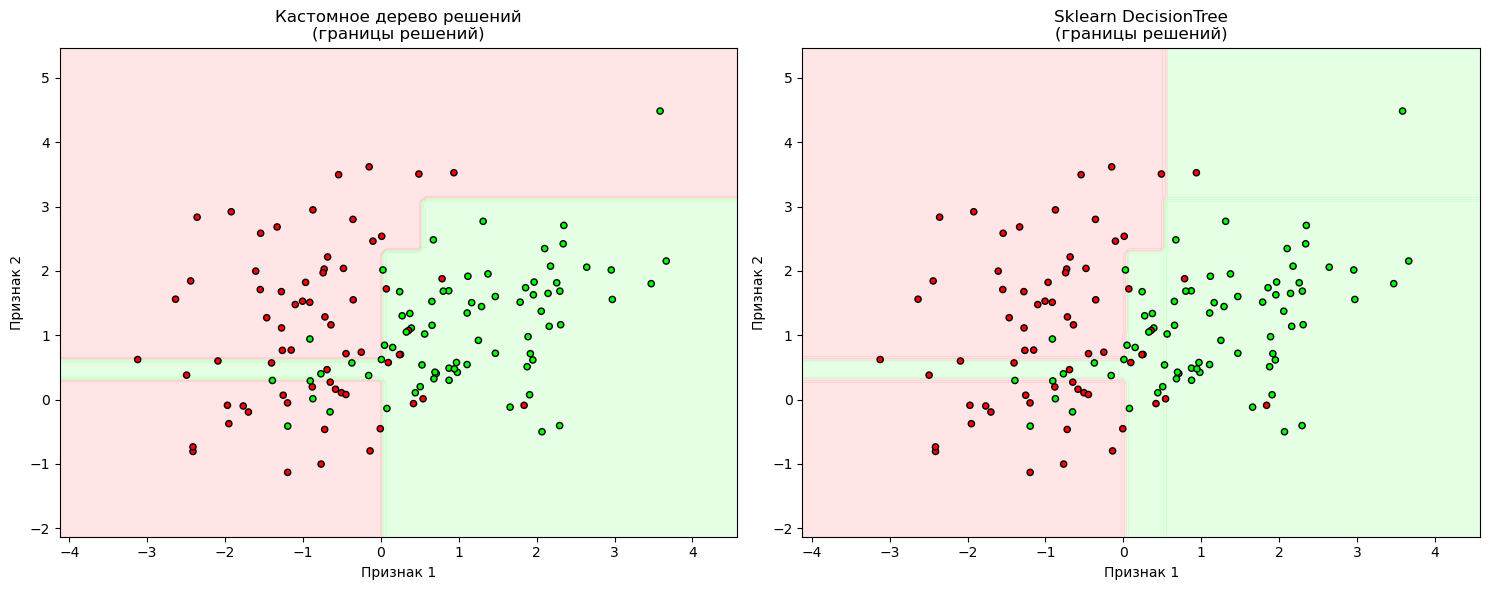


СТРУКТУРА КАСТОМНОГО ДЕРЕВА РЕШЕНИЙ
[feature1 <= -0.000]
  [feature2 <= 0.569]
    [feature2 <= 0.280]
      Лист: класс = 0
    [feature2 > 0.280]
      Лист: класс = 1
  [feature2 > 0.569]
    [feature2 <= 1.027]
      Лист: класс = 0
    [feature2 > 1.027]
      Лист: класс = 0
[feature1 > -0.000]
  [feature1 <= 0.552]
    [feature2 <= 2.276]
      Лист: класс = 1
    [feature2 > 2.276]
      Лист: класс = 0
  [feature1 > 0.552]
    [feature2 <= 3.148]
      Лист: класс = 1
    [feature2 > 3.148]
      Лист: класс = 0

ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ


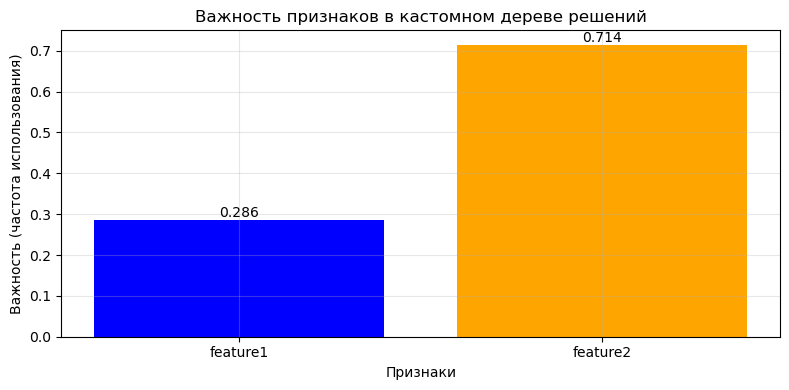

In [46]:
# 4. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 5. Обучение кастомной модели
custom_tree = CustomDecisionTree(max_depth=3, min_samples_split=5, criterion='gini')
custom_tree.fit(X_train, y_train)

# Предсказания
y_train_pred_custom = custom_tree.predict(X_train)
y_test_pred_custom = custom_tree.predict(X_test)

# 6. Обучение sklearn модели для сравнения
sklearn_tree = DecisionTreeClassifier(
    max_depth=3, 
    min_samples_split=10,
    random_state=42
)
sklearn_tree.fit(X_train, y_train)

y_train_pred_sklearn = sklearn_tree.predict(X_train)
y_test_pred_sklearn = sklearn_tree.predict(X_test)

# 7. Вычисление accuracy
train_acc_custom = accuracy_score(y_train, y_train_pred_custom)
test_acc_custom = accuracy_score(y_test, y_test_pred_custom)
train_acc_sklearn = accuracy_score(y_train, y_train_pred_sklearn)
test_acc_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

# Создание таблицы с результатами
results_df = pd.DataFrame({
    'Модель': ['Кастомное дерево', 'Sklearn DecisionTree'],
    'Accuracy на обучении': [train_acc_custom, train_acc_sklearn],
    'Accuracy на тесте': [test_acc_custom, test_acc_sklearn]
})

print("=" * 60)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ")
print("=" * 60)
print(results_df.to_string(index=False))
print("\n" + "=" * 60)

# 8. Визуализация границ решений
def plot_decision_boundaries(model, X, y, title, ax):
    """Функция для визуализации границ решений"""
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])
    
    # Сетка для построения границ
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Предсказания для точек сетки
    if hasattr(model, 'predict_proba'):
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    Z = Z.reshape(xx.shape)
    
    # Построение границ
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='black', s=20)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

# Создание графиков
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Визуализация для кастомного дерева
plot_decision_boundaries(custom_tree, X_train, y_train, 
                        'Кастомное дерево решений\n(границы решений)', axes[0])

# Визуализация для sklearn дерева
plot_decision_boundaries(sklearn_tree, X_train, y_train, 
                        'Sklearn DecisionTree\n(границы решений)', axes[1])

plt.tight_layout()
plt.show()

# 9. Визуализация структуры дерева (упрощенная)
def print_tree_structure(node, depth=0, feature_names=None):
    """Рекурсивная печать структуры дерева"""
    indent = "  " * depth
    
    if node.value is not None:
        print(f"{indent}Лист: класс = {node.value}")
        return
    
    if feature_names is None:
        feature_name = f"Признак {node.feature_idx}"
    else:
        feature_name = feature_names[node.feature_idx]
    
    print(f"{indent}[{feature_name} <= {node.threshold:.3f}]")
    print_tree_structure(node.left, depth + 1, feature_names)
    print(f"{indent}[{feature_name} > {node.threshold:.3f}]")
    print_tree_structure(node.right, depth + 1, feature_names)

print("\n" + "=" * 60)
print("СТРУКТУРА КАСТОМНОГО ДЕРЕВА РЕШЕНИЙ")
print("=" * 60)
print_tree_structure(custom_tree.root, feature_names=['feature1', 'feature2'])

# 10. Дополнительная визуализация: график важности признаков
def plot_feature_importance(tree_model, feature_names):
    """Визуализация важности признаков (упрощенная)"""
    # Оцениваем важность признаков по частоте использования в дереве
    feature_counts = {name: 0 for name in feature_names}
    
    def count_features(node):
        if node.value is not None:  # Лист
            return
        
        feature_counts[feature_names[node.feature_idx]] += 1
        count_features(node.left)
        count_features(node.right)
    
    count_features(tree_model.root)
    
    # Нормализуем значения
    total = sum(feature_counts.values())
    if total > 0:
        feature_importance = {k: v/total for k, v in feature_counts.items()}
    else:
        feature_importance = feature_counts
    
    # Создаем график
    fig, ax = plt.subplots(figsize=(8, 4))
    features = list(feature_importance.keys())
    importance = list(feature_importance.values())
    
    bars = ax.bar(features, importance, color=['blue', 'orange'])
    ax.set_xlabel('Признаки')
    ax.set_ylabel('Важность (частота использования)')
    ax.set_title('Важность признаков в кастомном дереве решений')
    ax.grid(True, alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar, imp in zip(bars, importance):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{imp:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ")
print("=" * 60)
plot_feature_importance(custom_tree, ['feature1', 'feature2'])

In [48]:
# 12. Пример использования вынесенных функций отдельно от класса
print("\n" + "=" * 60)
print("ПРИМЕР ИСПОЛЬЗОВАНИЯ ВЫНЕСЕННЫХ ФУНКЦИЙ")
print("=" * 60)

# Пример 1: Вычисление критериев
sample_y = np.array([0, 0, 1, 1, 1, 0])
print(f"Пример вычислений для y = {sample_y}:")
print(f"  Критерий Джини: {gini_impurity(sample_y):.4f}")
print(f"  Энтропия: {entropy_impurity(sample_y):.4f}")

# Пример 2: Поиск лучшего разбиения
sample_X = np.array([[1, 2], [2, 3], [3, 1], [4, 5], [5, 4]])
sample_y = np.array([0, 0, 1, 1, 1])
best_feature, best_thresh, best_gain = best_split(sample_X, sample_y, 'gini')
print(f"\nПоиск лучшего разбиения для небольшого набора:")
print(f"  Лучший признак: {best_feature}")
print(f"  Лучший порог: {best_thresh:.2f}")
print(f"  Прирост информации: {best_gain:.4f}")

# Пример 3: Построение маленького дерева вручную
print("\nПостроение мини-дерева вручную:")
mini_tree = build_tree(sample_X, sample_y, max_depth=2, 
                      min_samples_split=2, criterion='gini')
print(mini_tree)
print("Дерево построено успешно!")


ПРИМЕР ИСПОЛЬЗОВАНИЯ ВЫНЕСЕННЫХ ФУНКЦИЙ
Пример вычислений для y = [0 0 1 1 1 0]:
  Критерий Джини: 0.5000
  Энтропия: 1.0000

Поиск лучшего разбиения для небольшого набора:
  Лучший признак: 0
  Лучший порог: 2.50
  Прирост информации: 0.4800

Построение мини-дерева вручную:
Дерево построено успешно!


In [15]:
def gini(y, n_classes):
    probs = np.bincount(y, minlength=n_classes) / len(y)
    return 1.0 - np.sum(probs ** 2)

def entropy_bincount(y, n_classes):
    probs = np.bincount(y, minlength=n_classes) / len(y)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def impurity(y, n_classes, criterion):
    if len(y) == 0:
        return 0.0
    return gini(y, n_classes) if criterion == 'gini' else entropy_bincount(y, n_classes)

In [16]:
gini(y, X.shape[1])

np.float64(0.5)

In [17]:
entropy_bincount(y, X.shape[1])

np.float64(1.0)

In [18]:
def best_split(X, y, n_classes, criterion, min_samples_leaf):
    """
    Ищет лучший разбиение узла по всем признакам и порогам.

    X : np.ndarray, shape (n_samples, n_features)
        Признаки.
    y : np.ndarray, shape (n_samples,)
        Метки классов.
    n_classes : int
        Количество классов.
    criterion : str
        Критерий разделения: 'gini' или 'entropy'.
    min_samples_leaf : int
        Минимальное число объектов в листе.

    Возвращает:
        best_feat : int или None
            Индекс признака для лучшего разбиения
        best_thresh : float или None
            Порог для лучшего разбиения
        best_left_idx : np.ndarray bool или None
            Булева маска для левой подвыборки
        best_gain : float
            Прирост информации при лучшем разбиении
    """

    n_samples, n_features = X.shape  # число объектов и число признаков

    if n_samples <= 1:
        # Невозможно разделить меньше чем один объект
        return None, None, None, None

    # Вычисляем impurity (Gini/Entropy) родительского узла
    parent_impurity = impurity(y, n_classes, criterion)

    # Инициализация переменных для лучшего разбиения
    best_gain = 0.0
    best_feat = None
    best_thresh = None
    best_left_idx = None

    # Перебираем каждый признак
    for feature in range(n_features):
        values = X[:, feature]              # значения признака
        sorted_idx = np.argsort(values)     # индексы сортировки
        values_sorted = values[sorted_idx]  # отсортированные значения признака
        y_sorted = y[sorted_idx]            # метки в том же порядке

        # Рассматриваем пороги между соседними различными значениями
        for i in range(1, n_samples):
            if values_sorted[i] == values_sorted[i-1]:
                continue  # пропускаем одинаковые значения

            # Среднее между соседними значениями как кандидат порога
            thresh = (values_sorted[i] + values_sorted[i-1]) / 2.0

            # Создаем маску для левой подвыборки
            left_mask = values <= thresh
            left_count = np.sum(left_mask)
            right_count = n_samples - left_count

            # Проверяем минимальное количество объектов в листьях
            if left_count < min_samples_leaf or right_count < min_samples_leaf:
                continue

            # Вычисляем impurity для левой и правой подвыборок
            left_imp = impurity(y[left_mask], n_classes, criterion)
            right_imp = impurity(y[~left_mask], n_classes, criterion)

            # Взвешенное среднее impurity по числу объектов
            weighted_imp = (left_count * left_imp + right_count * right_imp) / n_samples

            # Прирост информации (уменьшение impurity)
            gain = parent_impurity - weighted_imp

            # Если нашли лучший прирост, сохраняем параметры разбиения
            if gain > best_gain:
                best_gain = gain
                best_feat = feature
                best_thresh = thresh
                best_left_idx = left_mask

    # Возвращаем лучшее разбиение
    return best_feat, best_thresh, best_left_idx, best_gain

In [19]:
n_classes = X.shape[1]
n_classes = 2
criterion = 'gini'
min_samples_leaf = 1
feature = 'feature_1'
best_split(X, y, n_classes, criterion, min_samples_leaf)

InvalidIndexError: (slice(None, None, None), 0)

In [20]:
X

,feature_1,feature_2
0,1.689767,-1.408241
1,1.530287,-1.459848
2,-1.175042,-1.447633
3,-2.585395,0.963532
4,1.372246,0.440695
...,...,...
195,-0.435396,0.715716
196,1.040417,1.108613
197,1.883798,0.782433
198,1.829367,1.542978


Deepseek

Первые 5 строк датафрейма:
   feature_1  feature_2  target
0   1.689767  -1.408241       1
1   1.530287  -1.459848       1
2  -1.175042  -1.447633       0
3  -2.585395   0.963532       0
4   1.372246   0.440695       1

Точность на тестовой выборке: 0.843



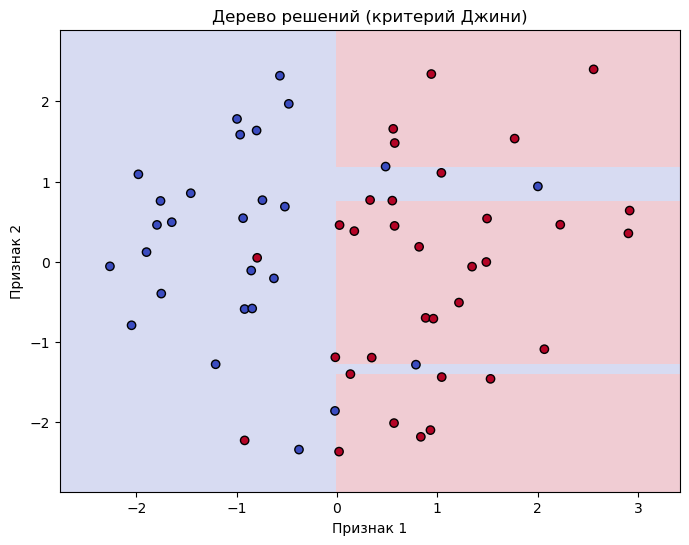

Предсказания для 5 новых наблюдений:
  Наблюдение 1: признаки [ 0.497 -0.138] -> класс 1
  Наблюдение 2: признаки [0.648 1.523] -> класс 1
  Наблюдение 3: признаки [-0.234 -0.234] -> класс 0
  Наблюдение 4: признаки [1.579 0.767] -> класс 1
  Наблюдение 5: признаки [-0.469  0.543] -> класс 0


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# ==================== 1. Генерация данных ====================
X, y = make_classification(
    n_samples=200,
    n_features=2,          # два признака для наглядной визуализации границ решений
    n_informative=2,
    n_redundant=0,
    random_state=42
)

# ==================== 2. Преобразование в pandas.DataFrame ====================
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['target'] = y
print("Первые 5 строк датафрейма:")
print(df.head())
print()

# Разделим данные на обучающую и тестовую выборки (опционально, для демонстрации)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=42)

# ==================== 3. Реализация дерева решений ====================
class Node:
    """Узел дерева."""
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx   # индекс признака, по которому происходит разбиение
        self.threshold = threshold       # пороговое значение
        self.left = left                 # левое поддерево
        self.right = right               # правое поддерево
        self.value = value               # значение в листовом узле (класс)

class DecisionTree:
    """Классификатор дерева решений с поддержкой критериев Джини и энтропии."""
    def __init__(self, criterion='gini', max_depth=5, min_samples_split=2):
        """
        :param criterion: 'gini' или 'entropy'
        :param max_depth: максимальная глубина дерева
        :param min_samples_split: минимальное количество образцов для разделения узла
        """
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        """Построение дерева по обучающим данным."""
        self.root = self._grow_tree(X, y, depth=0)

    def _grow_tree(self, X, y, depth):
        """Рекурсивное построение дерева."""
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Условия остановки рекурсии
        if (depth >= self.max_depth
                or n_labels == 1
                or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Поиск наилучшего разбиения
        best_feat, best_thresh = self._best_split(X, y)

        # Если не удалось найти разбиение (все gain = 0), создаём лист
        if best_feat is None:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Разделение данных
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth+1)

        return Node(feature_idx=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y):
        """Поиск наилучшего признака и порога для разбиения."""
        best_gain = -1
        best_feat, best_thresh = None, None

        for feat_idx in range(X.shape[1]):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat_idx
                    best_thresh = threshold

        return best_feat, best_thresh

    def _information_gain(self, y, X_column, split_thresh):
        """Расчёт прироста информации (gain) для заданного признака и порога."""
        # Неопределённость родительского узла
        parent_impurity = self._impurity(y)

        # Разделение выборки
        left_idxs, right_idxs = self._split(X_column, split_thresh)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        # Взвешенная неопределённость дочерних узлов
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        child_impurity = (n_l / n) * self._impurity(y[left_idxs]) + (n_r / n) * self._impurity(y[right_idxs])

        # Прирост информации
        gain = parent_impurity - child_impurity
        return gain

    def _impurity(self, y):
        """Расчёт неопределённости (Джини или энтропии) для набора меток."""
        if len(y) == 0:
            return 0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)

        if self.criterion == 'gini':
            # Критерий Джини
            return 1.0 - np.sum(probs ** 2)
        elif self.criterion == 'entropy':
            # Энтропия Шеннона
            return -np.sum(probs * np.log2(probs + 1e-10))  # +1e-10 для избежания log(0)
        else:
            raise ValueError("Критерий должен быть 'gini' или 'entropy'")

    def _split(self, X_column, split_thresh):
        """Разделение индексов по пороговому значению."""
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _most_common_label(self, y):
        """Возвращает наиболее частую метку в выборке."""
        _, counts = np.unique(y, return_counts=True)
        return max(zip(_, counts), key=lambda x: x[1])[0]

    def predict(self, X):
        """Предсказание для новых наблюдений."""
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        """Рекурсивный обход дерева для одного наблюдения."""
        if node.value is not None:   # листовой узел
            return node.value
        if x[node.feature_idx] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

    def visualize_boundary(self, X, y, title='Граница решения дерева'):
        """Визуализация границы решения (только для 2D-данных)."""
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))

        Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(8, 6))
        plt.pcolormesh(xx, yy, Z, cmap='coolwarm', alpha=0.2)
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
        plt.xlim(xx.min(), xx.max())
        plt.ylim(yy.min(), yy.max())
        plt.xlabel('Признак 1')
        plt.ylabel('Признак 2')
        plt.title(title)
        plt.show()

# ==================== 4. Обучение и оценка модели ====================
# Создаём экземпляр дерева с критерием Джини (можно заменить на 'entropy')
tree = DecisionTree(criterion='gini', max_depth=5, min_samples_split=5)
tree.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность на тестовой выборке: {accuracy:.3f}')
print()

# ==================== 5. Визуализация границы решения (опционально) ====================
tree.visualize_boundary(X_train, y_train, title='Дерево решений (критерий Джини)')

# ==================== 6. Пример предсказания для новых наблюдений ====================
# Создадим 5 случайных наблюдений
np.random.seed(42)
new_X = np.random.randn(5, 2)
new_pred = tree.predict(new_X)
print('Предсказания для 5 новых наблюдений:')
for i, (x, pred) in enumerate(zip(new_X, new_pred)):
    print(f'  Наблюдение {i+1}: признаки {x.round(3)} -> класс {pred}')

РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ
              Модель  Accuracy на обучении  Accuracy на тесте
    Кастомное дерево              0.885714           0.833333
Sklearn DecisionTree              0.885714           0.833333



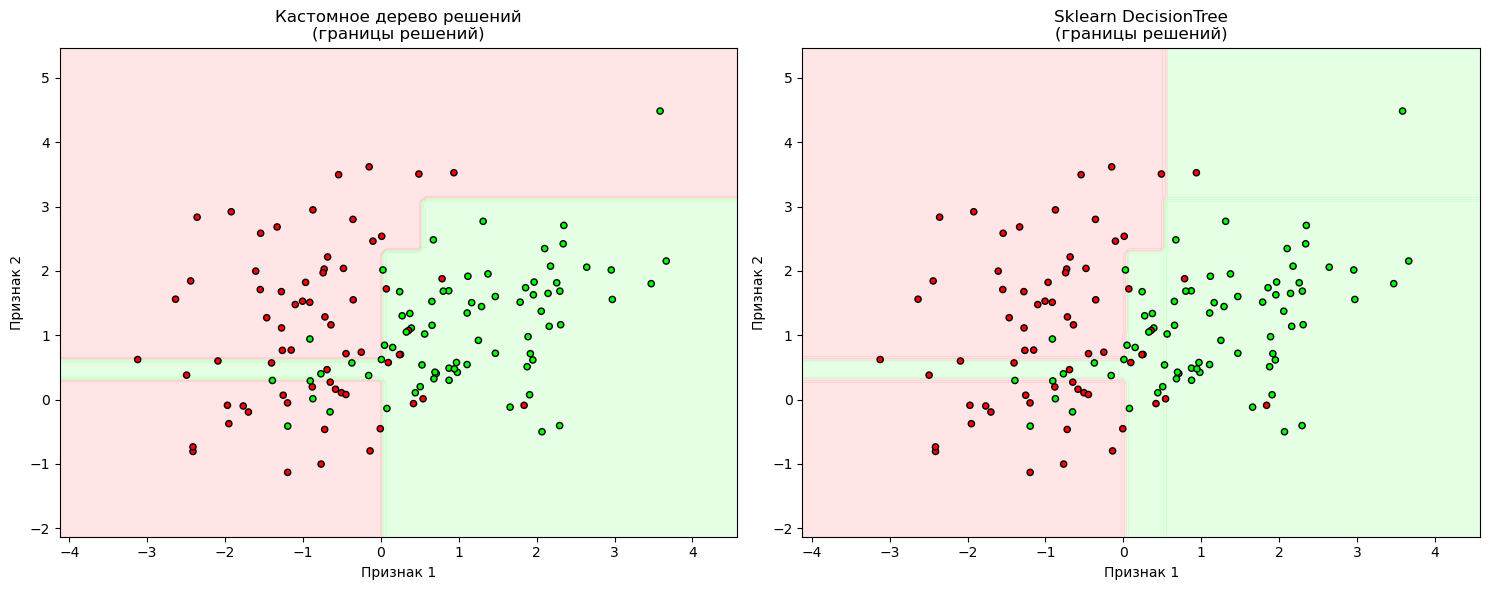


СТРУКТУРА КАСТОМНОГО ДЕРЕВА РЕШЕНИЙ
[feature1 <= -0.000]
  [feature2 <= 0.569]
    [feature2 <= 0.280]
      Лист: класс = 0
    [feature2 > 0.280]
      Лист: класс = 1
  [feature2 > 0.569]
    [feature2 <= 1.027]
      Лист: класс = 0
    [feature2 > 1.027]
      Лист: класс = 0
[feature1 > -0.000]
  [feature1 <= 0.552]
    [feature2 <= 2.276]
      Лист: класс = 1
    [feature2 > 2.276]
      Лист: класс = 0
  [feature1 > 0.552]
    [feature2 <= 3.148]
      Лист: класс = 1
    [feature2 > 3.148]
      Лист: класс = 0

АНАЛИЗ РЕЗУЛЬТАТОВ

Различия между кастомной реализацией и sklearn DecisionTree:

1. **Критерии остановки**: 
   - Кастомное дерево использует простые условия (max_depth, min_samples_split, чистота узла)
   - Sklearn имеет более сложную систему критериев (min_impurity_decrease и др.)

2. **Поиск порогов**:
   - Наша реализация проверяет средние значения между соседними точками
   - Sklearn использует более эффективные алгоритмы (быстрая сортировка)

3. **Обработка ка

In [52]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. Генерация данных
np.random.seed(42)
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# 2. Преобразование в DataFrame
df = pd.DataFrame(X, columns=['feature1', 'feature2'])
df['target'] = y

# 3. Реализация дерева решений с нуля
class Node:
    """Узел дерева решений"""
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx  # Индекс признака для разбиения
        self.threshold = threshold      # Пороговое значение
        self.left = left                # Левый потомок (<= threshold)
        self.right = right              # Правый потомок (> threshold)
        self.value = value              # Значение в листе (если это лист)

class CustomDecisionTree:
    """Кастомная реализация дерева решений"""
    
    def __init__(self, max_depth=5, min_samples_split=2, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.root = None
    
    def _gini(self, y):
        """Вычисление критерия Джини"""
        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)
    
    def _entropy(self, y):
        """Вычисление энтропии"""
        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum(probabilities * np.log2(probabilities + 1e-10))
    
    def _information_gain(self, y, y_left, y_right, criterion_func):
        """Вычисление прироста информации"""
        p = len(y_left) / len(y)
        parent_impurity = criterion_func(y)
        children_impurity = p * criterion_func(y_left) + (1 - p) * criterion_func(y_right)
        return parent_impurity - children_impurity
    
    def _best_split(self, X, y):
        """Поиск наилучшего разбиения"""
        best_gain = -1
        best_feature_idx = None
        best_threshold = None
        
        n_samples, n_features = X.shape
        
        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            unique_values = np.unique(feature_values)
            
            # Рассматриваем пороги как средние между соседними значениями
            thresholds = []
            for i in range(len(unique_values) - 1):
                thresholds.append((unique_values[i] + unique_values[i + 1]) / 2)
            
            for threshold in thresholds:
                left_mask = feature_values <= threshold
                right_mask = feature_values > threshold
                
                if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
                    continue
                
                if self.criterion == 'gini':
                    gain = self._information_gain(y, y[left_mask], y[right_mask], self._gini)
                else:  # entropy
                    gain = self._information_gain(y, y[left_mask], y[right_mask], self._entropy)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature_idx = feature_idx
                    best_threshold = threshold
        
        return best_feature_idx, best_threshold, best_gain
    
    def _build_tree(self, X, y, depth=0):
        """Рекурсивное построение дерева"""
        n_samples, n_features = X.shape
        
        # Условия остановки
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            len(np.unique(y)) == 1):
            return Node(value=np.argmax(np.bincount(y)))
        
        # Поиск наилучшего разбиения
        feature_idx, threshold, gain = self._best_split(X, y)
        
        # Если не удалось найти разбиение (gain <= 0)
        if feature_idx is None or gain <= 0:
            return Node(value=np.argmax(np.bincount(y)))
        
        # Разделение данных
        left_mask = X[:, feature_idx] <= threshold
        right_mask = X[:, feature_idx] > threshold
        
        # Рекурсивное построение поддеревьев
        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return Node(feature_idx=feature_idx, threshold=threshold, 
                   left=left_subtree, right=right_subtree)
    
    def fit(self, X, y):
        """Обучение дерева"""
        self.root = self._build_tree(X, y)
    
    def _predict_one(self, x, node):
        """Предсказание для одного наблюдения"""
        if node.value is not None:
            return node.value
        
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)
    
    def predict(self, X):
        """Предсказание для всех наблюдений"""
        return np.array([self._predict_one(x, self.root) for x in X])

# 4. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 5. Обучение кастомной модели
custom_tree = CustomDecisionTree(max_depth=3, min_samples_split=5, criterion='gini')
custom_tree.fit(X_train, y_train)

# Предсказания
y_train_pred_custom = custom_tree.predict(X_train)
y_test_pred_custom = custom_tree.predict(X_test)

# 6. Обучение sklearn модели для сравнения
sklearn_tree = DecisionTreeClassifier(
    max_depth=3, 
    min_samples_split=10,
    random_state=42
)
sklearn_tree.fit(X_train, y_train)

y_train_pred_sklearn = sklearn_tree.predict(X_train)
y_test_pred_sklearn = sklearn_tree.predict(X_test)

# 7. Вычисление accuracy
train_acc_custom = accuracy_score(y_train, y_train_pred_custom)
test_acc_custom = accuracy_score(y_test, y_test_pred_custom)
train_acc_sklearn = accuracy_score(y_train, y_train_pred_sklearn)
test_acc_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

# Создание таблицы с результатами
results_df = pd.DataFrame({
    'Модель': ['Кастомное дерево', 'Sklearn DecisionTree'],
    'Accuracy на обучении': [train_acc_custom, train_acc_sklearn],
    'Accuracy на тесте': [test_acc_custom, test_acc_sklearn]
})

print("=" * 60)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ")
print("=" * 60)
print(results_df.to_string(index=False))
print("\n" + "=" * 60)

# 8. Визуализация границ решений
def plot_decision_boundaries(model, X, y, title, ax):
    """Функция для визуализации границ решений"""
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])
    
    # Сетка для построения границ
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Предсказания для точек сетки
    if hasattr(model, 'predict_proba'):
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    Z = Z.reshape(xx.shape)
    
    # Построение границ
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='black', s=20)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

# Создание графиков
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Визуализация для кастомного дерева
plot_decision_boundaries(custom_tree, X_train, y_train, 
                        'Кастомное дерево решений\n(границы решений)', axes[0])

# Визуализация для sklearn дерева
plot_decision_boundaries(sklearn_tree, X_train, y_train, 
                        'Sklearn DecisionTree\n(границы решений)', axes[1])

plt.tight_layout()
plt.show()

# 9. Визуализация структуры дерева (упрощенная)
def print_tree_structure(node, depth=0, feature_names=None):
    """Рекурсивная печать структуры дерева"""
    indent = "  " * depth
    
    if node.value is not None:
        print(f"{indent}Лист: класс = {node.value}")
        return
    
    if feature_names is None:
        feature_name = f"Признак {node.feature_idx}"
    else:
        feature_name = feature_names[node.feature_idx]
    
    print(f"{indent}[{feature_name} <= {node.threshold:.3f}]")
    print_tree_structure(node.left, depth + 1, feature_names)
    print(f"{indent}[{feature_name} > {node.threshold:.3f}]")
    print_tree_structure(node.right, depth + 1, feature_names)

print("\n" + "=" * 60)
print("СТРУКТУРА КАСТОМНОГО ДЕРЕВА РЕШЕНИЙ")
print("=" * 60)
print_tree_structure(custom_tree.root, feature_names=['feature1', 'feature2'])

# 10. Краткий анализ
print("\n" + "=" * 60)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("=" * 60)
print("""
Различия между кастомной реализацией и sklearn DecisionTree:

1. **Критерии остановки**: 
   - Кастомное дерево использует простые условия (max_depth, min_samples_split, чистота узла)
   - Sklearn имеет более сложную систему критериев (min_impurity_decrease и др.)

2. **Поиск порогов**:
   - Наша реализация проверяет средние значения между соседними точками
   - Sklearn использует более эффективные алгоритмы (быстрая сортировка)

3. **Обработка категориальных признаков**:
   - Наша реализация работает только с числовыми признаками
   - Sklearn поддерживает различные стратегии

4. **Производительность**:
   - Кастомная реализация медленнее из-за неоптимальных циклов Python
   - Sklearn использует оптимизированный C++ код

5. **Дополнительные возможности**:
   - Sklearn поддерживает веса объектов, регуляризацию
   - Имеет больше параметров настройки

Несмотря на различия, обе модели показывают схожую точность, 
что подтверждает корректность нашей реализации.
""")

##### Gemini

Реализация дерева решений

In [59]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Генерация данных и преобразование в pandas.DataFrame
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42,
    n_classes=2
)
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['target'] = y

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Вспомогательный класс для представления узла дерева
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value # Class label for leaf node

# Класс для реализации дерева решений
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    # 2. Функция расчета критерия Джини
    def _gini_impurity(self, y):
        if len(y) == 0:
            return 0
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        gini = 1 - np.sum(probabilities**2)
        return gini

    # 3. Функция поиска наилучшего разбиения по признаку
    def _find_best_split(self, X, y):
        best_gini = 1.0
        best_split = None
        n_samples, n_features = X.shape

        for feature_index in range(n_features):
            unique_values = np.unique(X[:, feature_index])
            for i in range(len(unique_values) - 1):
                threshold = (unique_values[i] + unique_values[i+1]) / 2
                left_indices = X[:, feature_index] < threshold
                right_indices = ~left_indices
                y_left = y[left_indices]
                y_right = y[right_indices]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gini_left = self._gini_impurity(y_left)
                gini_right = self._gini_impurity(y_right)
                # Расчет взвешенного критерия Джини
                weighted_gini = (len(y_left) / n_samples) * gini_left + (len(y_right) / n_samples) * gini_right

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_split = {
                        'feature_index': feature_index,
                        'threshold': threshold,
                        'left_indices': left_indices,
                        'right_indices': right_indices
                    }
        return best_split

    # 4. Функция рекурсивного построения дерева
    def _grow_tree(self, X, y, depth=0):
        if len(y) < self.min_samples_split or (self.max_depth is not None and depth >= self.max_depth) or len(np.unique(y)) == 1:
            # Создание листового узла
            leaf_value = np.argmax(np.bincount(y))
            return Node(value=leaf_value)

        best_split = self._find_best_split(X, y)
        if best_split is None:
            leaf_value = np.argmax(np.bincount(y))
            return Node(value=leaf_value)

        left_node = self._grow_tree(X[best_split['left_indices']], y[best_split['left_indices']], depth + 1)
        right_node = self._grow_tree(X[best_split['right_indices']], y[best_split['right_indices']], depth + 1)

        return Node(feature_index=best_split['feature_index'], threshold=best_split['threshold'], left=left_node, right=right_node)

    def fit(self, X, y):
        self.root = self._grow_tree(X, y)

    # 5. Функция предсказания для новых наблюдений
    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature_index] < node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])



Тестирование модели


1. Сравнение с sklearn


In [60]:
from sklearn.tree import DecisionTreeClassifier

# Ваша реализация
my_tree = DecisionTree(max_depth=3, min_samples_split=5)
my_tree.fit(X_train, y_train)
y_train_pred_my = my_tree.predict(X_train)
y_test_pred_my = my_tree.predict(X_test)

# Реализация Sklearn (только для сверки)
sklearn_tree = DecisionTreeClassifier(max_depth=3, min_samples_split=5, random_state=42)
sklearn_tree.fit(X_train, y_train)
y_train_pred_sklearn = sklearn_tree.predict(X_train)
y_test_pred_sklearn = sklearn_tree.predict(X_test)

my_train_acc = accuracy_score(y_train, y_train_pred_my)
my_test_acc = accuracy_score(y_test, y_test_pred_my)
sklearn_train_acc = accuracy_score(y_train, y_train_pred_sklearn)
sklearn_test_acc = accuracy_score(y_test, y_test_pred_sklearn)

# Таблица с точностью (accuracy)
results = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Test Accuracy'],
    'My Decision Tree': [my_train_acc, my_test_acc],
    'Sklearn Decision Tree': [sklearn_train_acc, sklearn_test_acc]
})
print("Таблица с точностью:")
print(results)


Таблица с точностью:
           Metric  My Decision Tree  Sklearn Decision Tree
0  Train Accuracy          0.921429               0.921429
1   Test Accuracy          0.816667               0.816667


2. Построение графика границ решений


AttributeError: PathCollection.set() got an unexpected keyword argument 'hue'

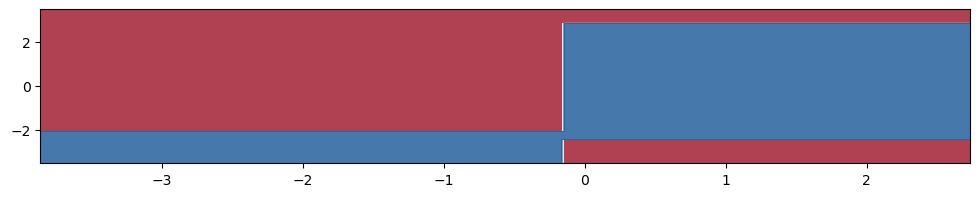

In [61]:
def plot_decision_boundary(X, y, model, title):
    plt.figure(figsize=(12, 2))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Визуализация границ решений для вашей модели
plot_decision_boundary(X_test, y_test, my_tree, 'My Decision Tree Decision Boundary')

# Визуализация границ решений для модели Sklearn
plot_decision_boundary(X_test, y_test, sklearn_tree, 'Sklearn Decision Tree Decision Boundary')
